# 🩺 Mini-ChatGPT na nazwach chorób
### Sympozjum „Nowoczesne technologie w pediatrii" · Kamil Jędryczek

Ten notebook buduje **mały model językowy** — dokładnie ten sam mechanizm, na którym opiera się ChatGPT, tylko ~100 miliardów razy mniejszy. Zamiast przewidywać następne **słowo** w zdaniu, przewidujemy następną **literę** w nazwie choroby.

**Jak uruchomić:** menu `Środowisko wykonawcze` → `Uruchom wszystko` (albo Ctrl+F9). Działa też na telefonie.

Trening trwa kilka minut. W tym czasie można czytać komentarze 🙂

In [1]:
# ── KONFIGURACJA ──────────────────────────────────────────────
# Który zbiór nazw trenujemy? Do wyboru: "choroby", "leki", "dinozaury"
ZBIOR = "choroby"

REPO = "https://raw.githubusercontent.com/NXTRSS/sympozjum-pediatria/main/data"

# Skąd wziąć dane (jedna nazwa na linię, bez nagłówka)
DANE = {
    "choroby":   f"{REPO}/choroby.csv",   # łacińskie nazwy chorób (Wikipedia PL/LA, CC BY-SA)
    "leki":      f"{REPO}/leki.csv",      # nazwy handlowe leków (Rejestr Produktów Leczniczych)
    "dinozaury": "https://raw.githubusercontent.com/junosuarez/dinosaurs/master/dinosaurs.csv",
}

LICZBA_EPOK = 120   # ile razy model zobaczy cały zbiór podczas nauki

In [2]:
# ── DANE ──────────────────────────────────────────────────────
import os
import pandas as pd

# Jeśli plik leży lokalnie (klon repo) — bierzemy go; inaczej pobieramy z GitHuba.
# Dzięki temu notebook działa też bez internetu, gdy padnie Wi-Fi na sali.
zrodlo = DANE[ZBIOR]
plik = os.path.basename(zrodlo)
for kandydat in (plik, f"data/{plik}", f"../data/{plik}"):
    if os.path.exists(kandydat):
        zrodlo = kandydat
        break

df = pd.read_csv(zrodlo, header=None, names=["nazwa"], sep="\t")
nazwy = (
    df["nazwa"].dropna().astype(str).str.strip().str.lower()
      .drop_duplicates().tolist()
)
print(f"Wczytano {len(nazwy)} nazw z: {zrodlo}\nPrzykłady:")
for n in nazwy[:8]:
    print("  •", n)

Wczytano 1465 nazw z: ../data/choroby.csv. Przykłady:
  • abdominalgia
  • ablepsia
  • abortus
  • abortus habitualis
  • abrasio dentium
  • abscessus brodie
  • abscessus cerebri
  • abscessus periapicalis


## Tokeny specjalne

Każdą nazwę opakowujemy w dwa znaki specjalne:
- `%` — **START**: „zacznij generować"
- `!` — **STOP**: „to już koniec nazwy"

Czyli `pneumonia` staje się `%pneumonia!`. Bez `%` model nie wiedziałby, od czego zacząć; bez `!` generowałby w nieskończoność.

In [3]:
# ── PRZYGOTOWANIE DANYCH ──────────────────────────────────────
import numpy as np

sekwencje = ["%" + n + "!" for n in nazwy]

# Słownik: każdy znak dostaje numer (0 rezerwujemy na "puste miejsce" / padding)
znaki = sorted(set("".join(sekwencje)))
znak2id = {z: i + 1 for i, z in enumerate(znaki)}
id2znak = {i: z for z, i in znak2id.items()}
WIELKOSC_SLOWNIKA = len(znaki) + 1
print(f"Słownik ma {WIELKOSC_SLOWNIKA} tokenów: {''.join(znaki)}")

# X = nazwa bez ostatniego znaku, Y = nazwa bez pierwszego znaku.
# Model uczy się: po każdym prefiksie przewidź NASTĘPNY znak.
#   X: %pneumonia     Y: pneumonia!
maks_dl = max(len(s) for s in sekwencje)
X = np.zeros((len(sekwencje), maks_dl - 1), dtype="int32")
Y = np.zeros((len(sekwencje), maks_dl - 1), dtype="int32")
for i, s in enumerate(sekwencje):
    ids = [znak2id[z] for z in s]
    X[i, :len(ids) - 1] = ids[:-1]
    Y[i, :len(ids) - 1] = ids[1:]
print(f"Macierz treningowa: {X.shape} (nazwy × pozycje znaków)")

Słownik ma 32 tokenów:  !%'-abcdefghijklmnopqrstuvwxyz
Macierz treningowa: (1465, 60) (nazwy × pozycje znaków)


## Model

Trzy warstwy, które robią całą magię:
1. **Embedding** — każda litera dostaje swój wektor liczb („znaczenie" litery),
2. **GRU** — sieć rekurencyjna z pamięcią: czyta literę po literze i pamięta kontekst,
3. **Dense + softmax** — zamienia pamięć na **rozkład prawdopodobieństwa** następnej litery.

ChatGPT różni się w środku (Transformer zamiast GRU) i skalą — ale wejście i wyjście ma identyczne: *kontekst → prawdopodobieństwa następnego tokenu*.

In [4]:
# ── TRENING ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Embedding(WIELKOSC_SLOWNIKA, 128, mask_zero=True),
    keras.layers.GRU(256, return_sequences=True),
    keras.layers.Dense(WIELKOSC_SLOWNIKA, activation="softmax"),
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam")

historia = model.fit(X, Y, epochs=LICZBA_EPOK, verbose=2)

Epoch 1/120


2026-08-28 14:26:24.008698: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-28 14:26:24.008907: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-08-28 14:26:24.008917: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1787919984.009097 3570649 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787919984.009591 3570649 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-08-28 14:26:24.472767: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


46/46 - 3s - 56ms/step - loss: 2.9442
Epoch 2/120
46/46 - 1s - 27ms/step - loss: 2.4366
Epoch 3/120
46/46 - 1s - 24ms/step - loss: 2.2957
Epoch 4/120
46/46 - 1s - 24ms/step - loss: 2.2178
Epoch 5/120
46/46 - 1s - 24ms/step - loss: 2.1481
Epoch 6/120
46/46 - 1s - 24ms/step - loss: 2.0825
Epoch 7/120
46/46 - 1s - 24ms/step - loss: 2.0146
Epoch 8/120
46/46 - 1s - 25ms/step - loss: 1.9455
Epoch 9/120
46/46 - 1s - 25ms/step - loss: 1.8806
Epoch 10/120
46/46 - 1s - 24ms/step - loss: 1.8142
Epoch 11/120
46/46 - 1s - 26ms/step - loss: 1.7515
Epoch 12/120
46/46 - 1s - 26ms/step - loss: 1.6862
Epoch 13/120
46/46 - 1s - 24ms/step - loss: 1.6210
Epoch 14/120
46/46 - 1s - 24ms/step - loss: 1.5605
Epoch 15/120
46/46 - 1s - 25ms/step - loss: 1.4964
Epoch 16/120
46/46 - 1s - 25ms/step - loss: 1.4364
Epoch 17/120
46/46 - 1s - 24ms/step - loss: 1.3745
Epoch 18/120
46/46 - 1s - 25ms/step - loss: 1.3163
Epoch 19/120
46/46 - 1s - 24ms/step - loss: 1.2589
Epoch 20/120
46/46 - 1s - 24ms/step - loss: 1.2021
E

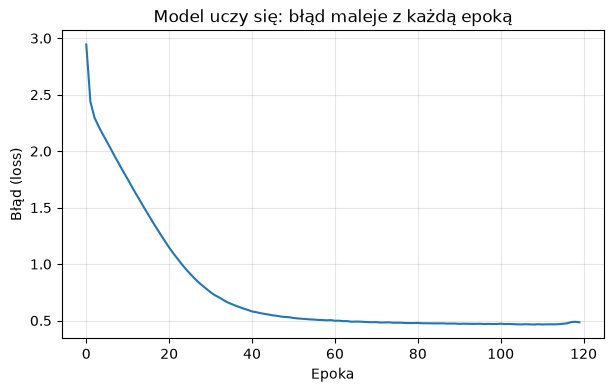

In [5]:
# ── KRZYWA UCZENIA ────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(historia.history["loss"])
plt.xlabel("Epoka"); plt.ylabel("Błąd (loss)")
plt.title("Model uczy się: błąd maleje z każdą epoką")
plt.grid(alpha=0.3); plt.show()

## Generowanie — serce autoregresji

Pętla jest banalna:
1. pokaż modelowi dotychczasowy kontekst (zaczynamy od `%`),
2. model zwraca **rozkład prawdopodobieństwa** wszystkich możliwych następnych liter,
3. **wylosuj** literę z tego rozkładu (temperatura steruje „odwagą" losowania),
4. dopisz literę do kontekstu i wróć do punktu 1 — aż wypadnie `!`.

Model **nigdy nie mówi „nie wiem"** — zawsze zwraca jakiś rozkład i zawsze coś wylosujemy. Zapamiętajcie to zdanie przy temacie halucynacji.

Na koniec sprawdzamy rzecz kluczową: **czy ta nazwa w ogóle istnieje w zbiorze treningowym?** Jeśli nie — model niczego nie skopiował, tylko nauczył się reguł budowy łacińskich nazw i złożył z nich nową.


In [6]:
# ── GENEROWANIE ───────────────────────────────────────────────
ZNANE = set(nazwy)   # zbiór treningowy — do sprawdzania, czy nazwa jest NAPRAWDĘ nowa

def generuj(temperatura=1.0, maks_znakow=40):
    """Zwraca (nazwa, kroki). Każdy krok = pełny rozkład P(następna litera | kontekst)."""
    kontekst, kroki = "%", []
    for _ in range(maks_znakow):
        ids = np.array([[znak2id[z] for z in kontekst]])
        rozklad = model.predict(ids, verbose=0)[0, -1]          # P(następna litera | kontekst)
        rozklad = np.log(rozklad + 1e-9) / temperatura           # temperatura
        rozklad = np.exp(rozklad) / np.exp(rozklad).sum()
        rozklad[0] = 0; rozklad /= rozklad.sum()                 # nie losujemy paddingu
        wybor = int(np.random.choice(len(rozklad), p=rozklad))
        kroki.append({"kontekst": kontekst, "rozklad": rozklad, "wybor": wybor})
        if id2znak[wybor] == "!":
            break
        kontekst += id2znak[wybor]
    return kontekst[1:], kroki   # bez tokenu startu


def werdykt(nazwa):
    """Czy model coś wymyślił, czy tylko odtworzył nazwę ze zbioru treningowego?"""
    if nazwa in ZNANE:
        return f"⚠️  \"{nazwa}\" JUŻ ISTNIEJE w zbiorze treningowym — model ją odtworzył, nie wymyślił."
    return f"✨ \"{nazwa.upper()}\" — tej nazwy NIE MA w zbiorze treningowym. Model ją wymyślił."


def pokaz_kroki(kroki):
    """Tekstowy ślad generowania: kontekst → top 5 kandydatów → wylosowana litera."""
    for krok in kroki:
        p, w = krok["rozklad"], krok["wybor"]
        top5 = np.argsort(p)[::-1][:5]
        opis = "  ".join(f"{id2znak[i]!r}:{p[i]:.0%}" for i in top5)
        print(f"  kontekst: {krok['kontekst']:<28} → wylosowano {id2znak[w]!r:<5} "
              f"(p={p[w]:.0%})   top5: {opis}")


def histogramy(kroki, kolumny=4):
    """Rozkład prawdopodobieństwa w każdym kroku. Pomarańczowy słupek = litera wylosowana."""
    litery = [id2znak[i] for i in range(1, WIELKOSC_SLOWNIKA)]
    wiersze = int(np.ceil(len(kroki) / kolumny))
    fig, axes = plt.subplots(wiersze, kolumny, figsize=(4.6 * kolumny, 2.9 * wiersze),
                             squeeze=False)
    for ax, krok in zip(axes.ravel(), kroki):
        p, w = krok["rozklad"][1:], krok["wybor"]
        kolory = ["#3A1C7D"] * len(p)
        kolory[w - 1] = "#FFAF7B"                     # wylosowana litera
        ax.bar(litery, p, color=kolory)
        ax.set_ylim(0, 1)
        ax.set_title(f"{krok['kontekst']}  →  {id2znak[w]!r}", fontsize=11)
        ax.tick_params(axis="x", labelsize=7)
        ax.grid(axis="y", alpha=0.25)
    for ax in axes.ravel()[len(kroki):]:
        ax.axis("off")
    fig.suptitle("P(następna litera | kontekst) — rozkład ostrzeje, gdy kontekst rośnie", y=1.0)
    fig.tight_layout()
    plt.show()


nazwa, kroki = generuj()
print("Ślad generowania — krok po kroku:\n")
pokaz_kroki(kroki)
print("\n" + werdykt(nazwa))
histogramy(kroki)

Jedno generowanie krok po kroku:

  kontekst: %                         → wybrano 's'   (top5: s:14%  c:12%  a:10%  p:9%  m:9%)
  kontekst: %s                        → wybrano 'y'   (top5: y:48%  t:14%  c:12%  p:7%  a:5%)
  kontekst: %sy                       → wybrano 'n'   (top5: n:86%  r:7%  m:3%  p:3%  l:0%)
  kontekst: %syn                      → wybrano 'd'   (top5: d:99%  c:1%  u:0%  o:0%  e:0%)
  kontekst: %synd                     → wybrano 'r'   (top5: r:100%  a:0%  o:0%  l:0%  i:0%)
  kontekst: %syndr                    → wybrano 'o'   (top5: o:100%  a:0%  e:0%  t:0%  i:0%)
  kontekst: %syndro                   → wybrano 'm'   (top5: m:100%  p:0%  a:0%  t:0%  c:0%)
  kontekst: %syndrom                  → wybrano 'a'   (top5: a:100%  y:0%  e:0%  b:0%  !:0%)
  kontekst: %syndroma                 → wybrano ' '   (top5:  :100%  t:0%  c:0%  !:0%  l:0%)
  kontekst: %syndroma                 → wybrano 'n'   (top5: n:14%  c:11%  s:10%  m:7%  l:7%)
  kontekst: %syndroma n            

In [7]:
# ── 10 NOWYCH NAZW ────────────────────────────────────────────
nowe = 0
for _ in range(10):
    nazwa, _ = generuj(temperatura=1.0)
    if nazwa in ZNANE:
        print(f" • {nazwa:<40} ⚠️  istnieje w zbiorze treningowym")
    else:
        print(f" • {nazwa:<40} ✨ nowa")
        nowe += 1
print(f"\n{nowe}/10 nazw nie występuje w zbiorze treningowym.")

 • otitis externa fabilis acuta
 • acrophobia
 • febris endermoloides chronica
 • neurodemina
 • sarcoma
 • borrelios
 • lei kalgiana
 • constantinus anigodis
 • simii alati
 • anaemia drepanocytica


### Eksport śladu generowania (do slajdu w prezentacji)

Poniższa komórka generuje jedną nazwę i zapisuje wszystkie kroki (rozkłady, wybory) jako JSON w formacie slajdu „Krok po kroku". Uruchamiaj, aż wypadnie nazwa, która Ci się podoba — potem skopiuj JSON.

In [ ]:
# ── ŚLAD GENEROWANIA → JSON POD SLAJD ─────────────────────────
import json

nazwa, kroki = generuj()
print(werdykt(nazwa) + f"   ({len(kroki)} kroków)\n")

eksport = []
for krok in kroki:
    p, w = krok["rozklad"], krok["wybor"]
    top5 = np.argsort(p)[::-1][:5]
    probs = [[id2znak[int(i)], round(float(p[i]), 2)] for i in top5]
    probs.append(["…", round(max(0.0, 1 - sum(x for _, x in probs)), 2)])
    eksport.append({
        "context": krok["kontekst"],
        "probs": probs,
        "chosen": id2znak[w],
        "top": id2znak[int(top5[0])],
    })

print(json.dumps(eksport, ensure_ascii=False, indent=2))

## 📱 Aplikacja dla całej sali (Gradio)

Ostatnia komórka odpala prostą aplikację webową z **publicznym linkiem** (`*.gradio.live`, ważny 72 h). Wystarczy zrobić z niego kod QR — każdy telefon na sali może generować nazwy, bez logowania.

In [ ]:
# ── GRADIO ────────────────────────────────────────────────────
!pip -q install gradio

import gradio as gr

def app_generuj(ile, temperatura):
    wyniki = []
    for _ in range(int(ile)):
        nazwa, _ = generuj(temperatura=temperatura)
        znacznik = "  (istnieje w zbiorze)" if nazwa in ZNANE else ""
        wyniki.append(f"• {nazwa}{znacznik}")
    return "\n".join(wyniki)

demo = gr.Interface(
    fn=app_generuj,
    inputs=[
        gr.Slider(1, 10, value=5, step=1, label="Ile nazw wygenerować?"),
        gr.Slider(0.2, 1.8, value=1.0, step=0.1, label="Kreatywność (temperatura)"),
    ],
    outputs=gr.Textbox(label="Nowe nazwy — właśnie wymyślone przez model", lines=10),
    title=f"🩺 Generator: {ZBIOR}",
    description="Mały model językowy (GRU) wytrenowany na żywo podczas prelekcji. "
                "Ten sam mechanizm co w ChatGPT — tylko mniejszy o ~11 rzędów wielkości.",
)
demo.launch(share=True)